In [24]:
import os
import pandas as pd
import numpy as np
import math
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

True

In [25]:
path = os.environ['PROJECT_FOLDER']
path

'D:\\1.Work\\WorkStation\\WorkSpace\\Projects\\Dynamic-Portfolio-Allocation'

In [26]:
with open(os.path.join(path,'config.yaml')) as f:
    config = yaml.safe_load(f)

In [ ]:
# So i was thinking of creating new features using OHLCV values

In [ ]:
# Idea: 
'''
    x-axis: V(H-L)
    y-axis: V(C-O)
'''

In [8]:
ticker = config['features']['forex'][2]    # Testing on GPBUSD
data = pd.read_csv(os.path.join(path,'data','raw',f'{ticker}.csv'))

In [9]:
data

,Date,GBPUSD=X_Open,GBPUSD=X_High,GBPUSD=X_Low,GBPUSD=X_Close,GBPUSD=X_Volume,GBPUSD=X_Dividends,GBPUSD=X_StockSplits
0,2003-12-01 00:00:00+00:00,1.723811,1.727205,1.718390,1.718597,0,0.0,0.0
1,2003-12-02 00:00:00+00:00,1.719010,1.732112,1.717298,1.730313,0,0.0,0.0
2,2003-12-03 00:00:00+00:00,1.730493,1.731812,1.725209,1.728101,0,0.0,0.0
3,2003-12-04 00:00:00+00:00,1.727414,1.728997,1.718302,1.720697,0,0.0,0.0
4,2003-12-05 00:00:00+00:00,1.720608,1.733102,1.719809,1.733102,0,0.0,0.0
...,...,...,...,...,...,...,...,...
5861,2026-06-18 00:00:00+01:00,1.330477,1.332623,1.320707,1.330123,0,0.0,0.0
5862,2026-06-19 00:00:00+01:00,1.320550,1.324152,1.316378,1.320202,0,0.0,0.0
5863,2026-06-22 00:00:00+01:00,1.320830,1.327211,1.318513,1.320795,0,0.0,0.0
5864,2026-06-23 00:00:00+01:00,1.324644,1.325030,1.318635,1.324714,0,0.0,0.0


In [20]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5866 entries, 0 to 5865
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  5866 non-null   str    
 1   GBPUSD=X_Open         5866 non-null   float64
 2   GBPUSD=X_High         5866 non-null   float64
 3   GBPUSD=X_Low          5866 non-null   float64
 4   GBPUSD=X_Close        5866 non-null   float64
 5   GBPUSD=X_Volume       5866 non-null   int64  
 6   GBPUSD=X_Dividends    5866 non-null   float64
 7   GBPUSD=X_StockSplits  5866 non-null   float64
dtypes: float64(6), int64(1), str(1)
memory usage: 510.0 KB


In [49]:
x = (data[f'{ticker}_High']-data[f'{ticker}_Low'])
y = (data[f'{ticker}_Close']-data[f'{ticker}_Open'])
date = data['Date']
df = pd.DataFrame({'Date':date,'HL':x,'OC':y})

In [50]:
df['Volatility'] = np.sqrt(df['HL']**2 + df['OC']**2)
df['Theta'] = np.arctan(df['OC']/df['HL'])
df['Theta'] = df['Theta'].apply(lambda x: x * 180 / math.pi)

In [54]:
df.reset_index(names='ID',inplace=True)

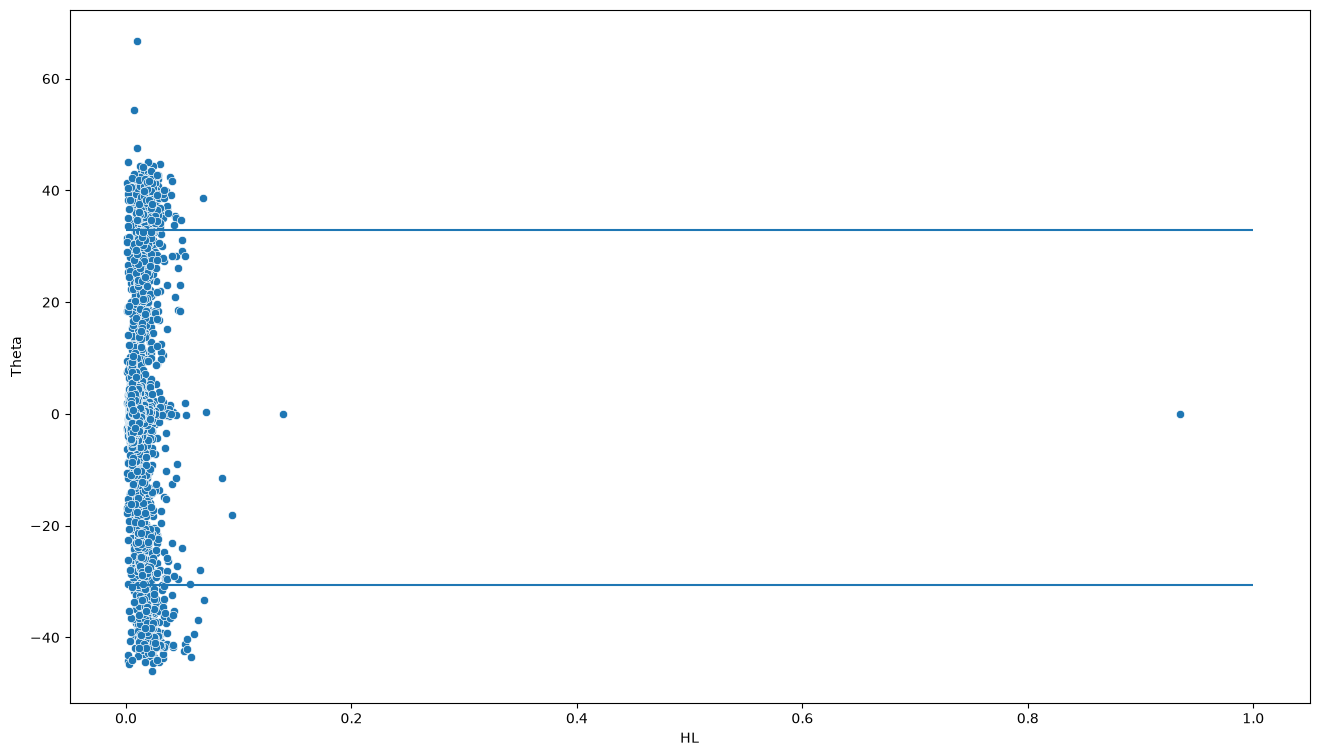

In [63]:
fig,ax = plt.subplots(figsize=(16,9))

sns.scatterplot(
    x='HL',
    y='Theta',
    data=df
)

plt.hlines(y=df['Theta'].quantile(0.95),xmin=0,xmax=1)
plt.hlines(y=df['Theta'].quantile(0.05),xmin=0,xmax=1)

In [ ]:
# Maybe for my research paper, I can patch values using this method, i.e. binning a patch based on volatility and theta. This has to be done after normalization
# 

In [1]:
## Making the weekly returns

In [17]:
data['GBPUSD=X_7DReturn'] = 100*(data['GBPUSD=X_Close'] - data['GBPUSD=X_Close'].shift(7))

In [22]:
data['GBPUSD=X_7DReturn'].fillna(0)

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
5861   -0.321007
5862   -1.701844
5863   -1.540709
5864   -1.666772
5865   -2.921700
Name: GBPUSD=X_7DReturn, Length: 5866, dtype: float64

In [ ]:
# Ok so now first I will have to create the dataset and then will move onto next steps
# So for training data, I will have to take the intersection of datasets and then take the intersection

In [27]:
stocks = []
for i in range(len(config['stocks'])):
    stocks.append(config['stocks'][i][0])

In [ ]:
features = config['features']['commodities'] + config['features']['forex'] + config['features']['w_indices'] + config['features']['other']
instruments = stocks + features
instruments.remove('JIOFIN.NS')
instruments.remove('TMCV.NS')

In [76]:
common_idx = None

for i in instruments:
    data = pd.read_csv(os.path.join(path,'data','processed',f'p-{i}.csv'))
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date',inplace=True)
    common_idx = data.index if common_idx is None else common_idx.intersection(data.index)

common_idx = common_idx.sort_values()

In [77]:
print(type(data.index))
print(data.index.dtype)


<class 'pandas.DatetimeIndex'>
datetime64[us]


In [78]:
common_idx

DatetimeIndex(['2021-07-26', '2021-07-27', '2021-07-28', '2021-07-29',
               '2021-08-02', '2021-08-03', '2021-08-04', '2021-08-05',
               '2021-08-09', '2021-08-10',
               ...
               '2026-06-03', '2026-06-04', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-15', '2026-06-16',
               '2026-06-17', '2026-06-22'],
              dtype='datetime64[us]', name='Date', length=823, freq=None)

In [79]:
dataframes = []
fstocks = []

for i in features:
    data = pd.read_csv(os.path.join(path,'data','processed',f'p-{i}.csv'))
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date',inplace=True)
    data = data.loc[common_idx]
    dataframes.append(data)

for i in ["TATASTEEL.NS", "SUNPHARMA.NS", "RELIANCE.NS", "INFY.NS", "TATACONSUM.NS"]:
    data = pd.read_csv(os.path.join(path,'data','processed',f'p-{i}.csv'))
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date',inplace=True)
    data = data.loc[common_idx]
    fstocks.append(data)

In [80]:
dataset = pd.concat(dataframes,axis=1)
stks = pd.concat(fstocks,axis=1)

In [81]:
dataset.to_csv(os.path.join(path,'data','final','Dataset.csv'))
stks.to_csv(os.path.join(path,'data','final','Stocks.csv'))

In [82]:
dataset

,GC=F_Open,GC=F_High,GC=F_Low,GC=F_Close,GC=F_Volume,GC=F_HL,GC=F_OC,GC=F_Volatility,GC=F_Theta,SI=F_Open,...,^VIX_Theta,^INDIAVIX_Open,^INDIAVIX_High,^INDIAVIX_Low,^INDIAVIX_Close,^INDIAVIX_Volume,^INDIAVIX_HL,^INDIAVIX_OC,^INDIAVIX_Volatility,^INDIAVIX_Theta
Date,,,,,,,,,,,,,,,,,,,,,
2021-07-26,0.566466,0.554025,0.573765,0.562383,-0.177901,-0.398094,-0.199807,-0.387302,-1.026319,0.488078,...,-0.902472,-0.800942,-0.677907,-0.742626,-0.727342,0.0,-0.330258,0.327226,-0.316902,1.364852
2021-07-27,0.567861,0.555410,0.576461,0.563314,-0.178567,-0.445094,-0.221287,-0.407848,-1.287415,0.480603,...,0.886069,-0.715969,-0.464367,-0.832541,-0.676435,0.0,0.302109,0.192966,0.238089,0.317197
2021-07-28,0.562978,0.550563,0.576461,0.563314,8.553311,-0.624530,0.004308,-0.617556,NaN,0.444013,...,-0.803082,-0.665857,-0.663961,-0.701314,-0.758329,0.0,-0.365939,-0.310509,-0.349361,-1.342255
2021-07-29,0.571232,0.588759,0.584198,0.600183,1.090744,0.507636,1.325668,0.659063,1.163694,0.468013,...,-0.318706,-0.746472,-0.696210,-0.732906,-0.774929,0.0,-0.387745,-0.062967,-0.405118,-0.285220
2021-08-02,0.577975,0.572719,0.582674,0.584947,-0.123083,-0.030681,0.310475,-0.087138,0.589807,0.500275,...,1.469348,-0.761724,-0.644786,-0.759637,-0.669794,0.0,-0.227176,0.394356,-0.218231,1.233509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,3.171111,3.331902,3.192450,3.227700,-0.097942,7.014377,2.550353,5.913315,0.382008,3.530152,...,-0.862129,-0.456695,-0.496616,-0.463162,-0.562447,0.0,-0.373869,-0.373443,-0.340256,-1.603219
2026-06-15,3.436528,3.507532,3.471575,3.504164,-0.109264,3.344455,3.055245,3.226909,0.844899,4.011014,...,-1.023509,-0.593958,-0.606436,-0.632056,-0.712955,0.0,-0.348098,-0.415400,-0.310061,-1.608766
2026-06-16,3.481055,3.488838,3.518936,3.507537,-0.172032,0.926316,1.153780,0.870201,0.819201,3.997873,...,0.839846,-0.701807,-0.677907,-0.712250,-0.731769,0.0,-0.379816,-0.071359,-0.397318,-0.317312


In [ ]:

# Use this function to check the length 
for i in instruments:
    data = pd.read_csv(
        os.path.join(path, 'data', 'processed', f'p-{i}.csv'),
        parse_dates=['Date']
    )

    data.set_index('Date', inplace=True)

    print(
        f"{i:15} "    # :15 states that reserve 15 characters for i
        f"Rows={len(data):5} "
        f"Start={data.index.min()} "
        f"End={data.index.max()}"
    )


# So this is the problem, I was getting only 101 rows after intersection and that is because TMCV has only 150 days of data so I will remove that also JIOFIN (700 days)

ADANIENT.NS     Rows= 5956 Start=2002-06-30 00:00:00 End=2026-06-23 00:00:00
ADANIPORTS.NS   Rows= 4580 Start=2007-11-26 00:00:00 End=2026-06-23 00:00:00
APOLLOHOSP.NS   Rows= 5954 Start=2002-06-30 00:00:00 End=2026-06-23 00:00:00
ASIANPAINT.NS   Rows= 5954 Start=2002-06-30 00:00:00 End=2026-06-23 00:00:00
AXISBANK.NS     Rows= 6890 Start=1998-11-26 00:00:00 End=2026-06-23 00:00:00
BAJAJ-AUTO.NS   Rows= 5957 Start=2002-06-30 00:00:00 End=2026-06-23 00:00:00
BAJFINANCE.NS   Rows= 5954 Start=2002-06-30 00:00:00 End=2026-06-23 00:00:00
BAJAJFINSV.NS   Rows= 5923 Start=2002-08-11 00:00:00 End=2026-06-23 00:00:00
BEL.NS          Rows= 5954 Start=2002-06-30 00:00:00 End=2026-06-23 00:00:00
BHARTIARTL.NS   Rows= 5954 Start=2002-06-30 00:00:00 End=2026-06-23 00:00:00
CIPLA.NS        Rows= 7651 Start=1995-12-31 00:00:00 End=2026-06-23 00:00:00
COALINDIA.NS    Rows= 3857 Start=2010-11-03 00:00:00 End=2026-06-23 00:00:00
DRREDDY.NS      Rows= 7649 Start=1995-12-31 00:00:00 End=2026-06-23 00:00:00

### Model

In [ ]:
# So now that I have got the dataset, I will 

In [1]:
from datetime import datetime

In [13]:
str(datetime.now().strftime("%d/%m/%y-%H:%M:%S"))

'26/06/26-17:17:11'